In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read in data
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
unit_sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [7]:
unit_sales.tail()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0
30489,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,2,0,5,4,0,2,2,5,1


In [4]:
prices = pd.read_csv("../data/sell_prices.csv")
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [8]:
prices.tail()

,store_id,item_id,wm_yr_wk,sell_price
6841116,WI_3,FOODS_3_827,11617,1.0
6841117,WI_3,FOODS_3_827,11618,1.0
6841118,WI_3,FOODS_3_827,11619,1.0
6841119,WI_3,FOODS_3_827,11620,1.0
6841120,WI_3,FOODS_3_827,11621,1.0


In [5]:
calendar = pd.read_csv("../data/calendar.csv")
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
calendar.tail()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


EDA Checklist (from Robert Peng's Exploratory Data Analysis with R)
1. Formulate your question
2. Read in your data DONE
3. Check the packaging DONE
4. Run str() DONE
5. Look at the top and bottom of your data DONE
6. Check your "n"s DONE
7. Validate with atleast one external data source
8. Try the easy solution first
9. Challenge your solution
10. Follow-up

In [9]:
print(f"Shape of unit sales table: {unit_sales.shape}")
print(f"Shape of prices table: {prices.shape}")
print(f"Shape of calendar table: {calendar.shape}")

Shape of unit sales table: (30490, 1947)
Shape of prices table: (6841121, 4)
Shape of calendar table: (1969, 14)


4. Run str()

In [10]:
unit_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


In [11]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [12]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [15]:
calendar.groupby(by=["year"]).count()

,date,wm_yr_wk,weekday,wday,month,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
year,,,,,,,,,,,,,
2011,337,337,337,337,337,337,26,26,1,1,337,337,337
2012,366,366,366,366,366,366,30,30,0,0,366,366,366
2013,365,365,365,365,365,365,29,29,1,1,365,365,365
2014,365,365,365,365,365,365,28,28,2,2,365,365,365
2015,365,365,365,365,365,365,30,30,0,0,365,365,365
2016,171,171,171,171,171,171,19,19,1,1,171,171,171


In [17]:
print((calendar["wm_yr_wk"].min(),calendar["wm_yr_wk"].max()))
print((prices["wm_yr_wk"].min(),prices["wm_yr_wk"].max()))

(np.int64(11101), np.int64(11621))
(np.int64(11101), np.int64(11621))


In [41]:
products = prices["item_id"].unique()

np.random.seed(2001)
products_sample = products[np.random.randint(0,products.shape[0],size=10)]
products_sample

array(['HOUSEHOLD_2_445', 'FOODS_3_214', 'FOODS_2_238', 'FOODS_3_522',
       'HOUSEHOLD_1_443', 'FOODS_1_027', 'FOODS_1_135', 'FOODS_3_593',
       'FOODS_3_464', 'HOBBIES_1_043'], dtype=object)

[]

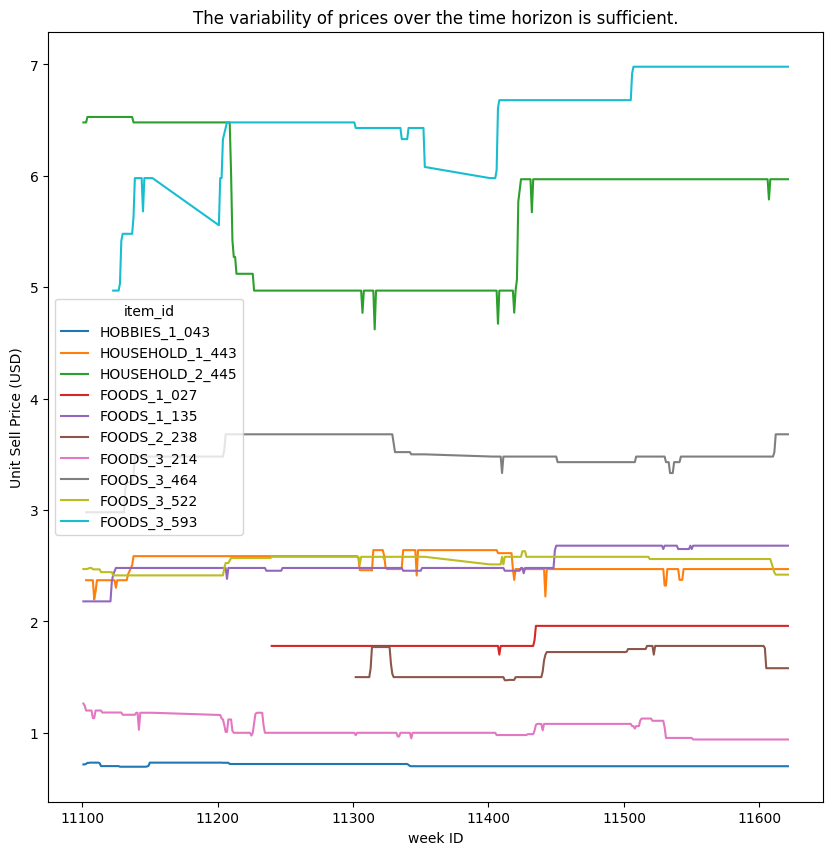

In [ ]:
plot_df = prices.loc[prices["item_id"].isin(products_sample)]

plt.figure(figsize=(10,10))
sns.lineplot(data=plot_df,
             x="wm_yr_wk",
             y="sell_price",
             hue="item_id",
             errorbar=None)
plt.xlabel("week ID")
plt.ylabel("Unit Sell Price (USD)")
plt.title("The variability of prices over the time horizon is sufficient.")
plt.plot()

In [57]:
standard_deviations = prices[["item_id","sell_price"]].groupby(by="item_id").std().reset_index()

In [58]:
standard_deviations

,item_id,sell_price
0,FOODS_1_001,0.116225
1,FOODS_1_002,0.485684
2,FOODS_1_003,0.156082
3,FOODS_1_004,0.106627
4,FOODS_1_005,0.196211
...,...,...
3044,HOUSEHOLD_2_512,0.026996
3045,HOUSEHOLD_2_513,0.000000
3046,HOUSEHOLD_2_514,0.916503
3047,HOUSEHOLD_2_515,0.027617


In [62]:
standard_deviations["category"] = standard_deviations["item_id"].str.extract(r'(HOUSEHOLD|FOODS|HOBBIES)')
standard_deviations.groupby('category').median(numeric_only=True).reset_index()

,category,sell_price
0,FOODS,0.126944
1,HOBBIES,0.100428
2,HOUSEHOLD,0.125474
